Total Sales: 200200
Average Sales: 16683.333333333332
Highest Sales: 50000
Lowest Sales: 2000
Product Sales:     Product   Sales
0  Keyboard   10500
1    Laptop  143000
2   Monitor   40000
3     Mouse    6700
Region Sales:   Region  Sales
0   East  66500
1  North  67200
2  South  51000
3   West  15500
Best Product: Laptop
Best Region: North
Total Quantity: 155
Average Quantity: 12.916666666666666


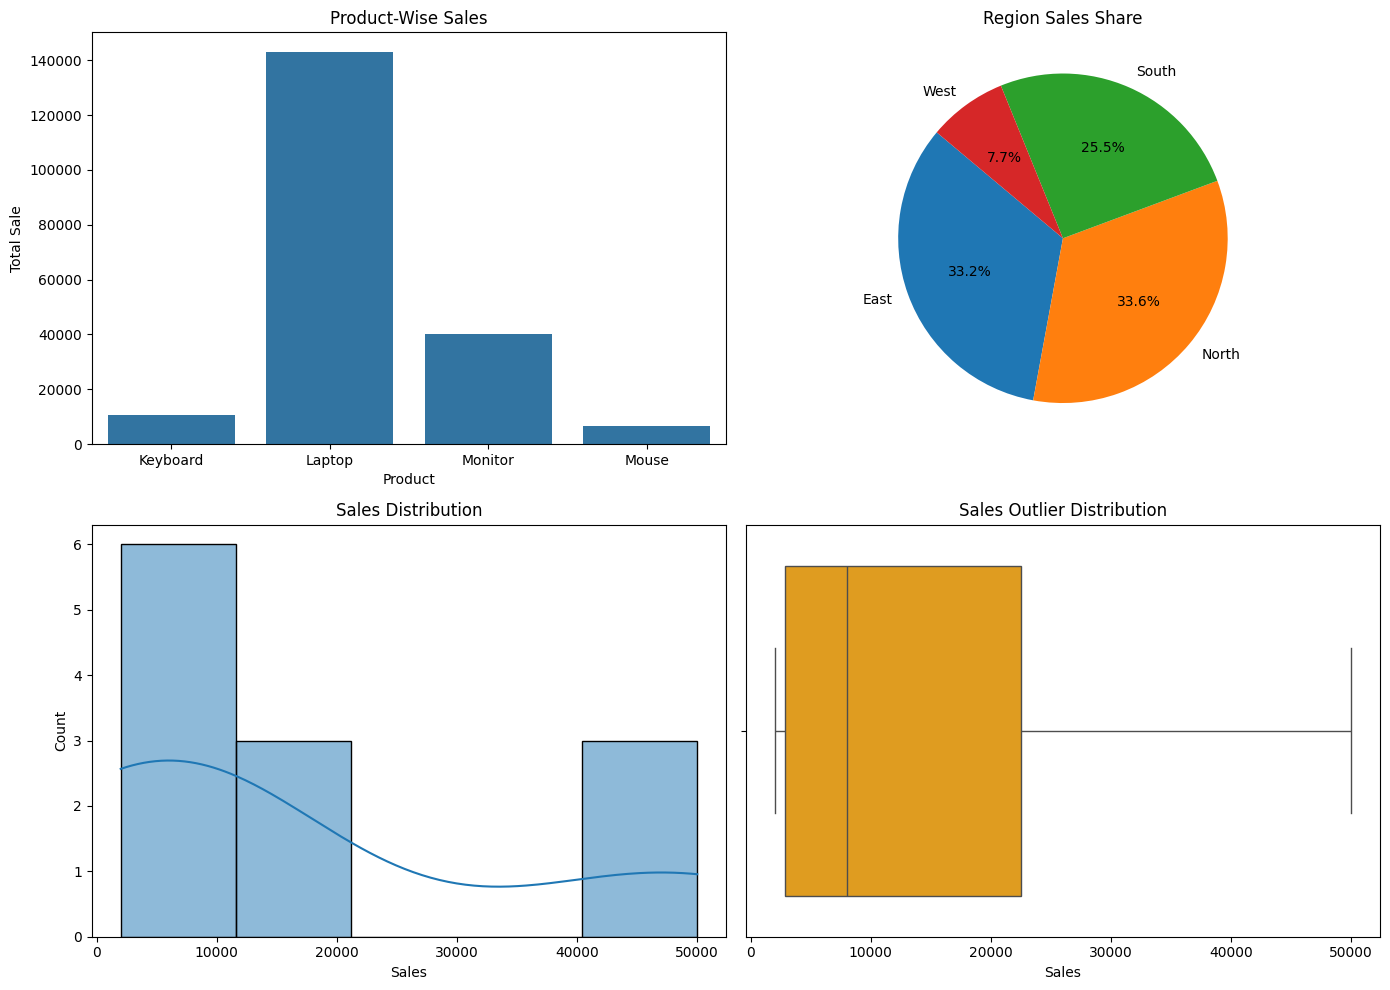

Files saved successfully.


In [14]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

df = pd.read_csv('sales_data.csv')

total_sales = df['Sales'].sum()
average_sales = df['Sales'].mean()
highest_sales = df['Sales'].max()
lowest_sales = df['Sales'].min()

product_sales = df.groupby('Product')['Sales'].sum().reset_index()
region_sales = df.groupby('Region')['Sales'].sum().reset_index()

best_product = df.groupby('Product')['Sales'].sum().idxmax()
best_region = df.groupby('Region')['Sales'].sum().idxmax()

total_quantity = df['Quantity'].sum()
average_quantity = df['Quantity'].mean()

print(f"Total Sales: {total_sales}")
print(f"Average Sales: {average_sales}")
print(f"Highest Sales: {highest_sales}")
print(f"Lowest Sales: {lowest_sales}")
print(f"Product Sales: {product_sales}")
print(f"Region Sales: {region_sales}")
print(f"Best Product: {best_product}")
print(f"Best Region: {best_region}")
print(f"Total Quantity: {total_quantity}")
print(f"Average Quantity: {average_quantity}")

fig, axes = plt.subplots(2, 2, figsize=(14,10))
axes = axes.flatten()

sns.barplot(
    x='Product',
    y='Sales',
    ax=axes[0],
    data=product_sales
)
axes[0].set_title('Product-Wise Sales')
axes[0].set_ylabel('Total Sale')

axes[1].pie(region_sales['Sales'], labels=region_sales['Region'], autopct='%1.1f%%', startangle=140)
axes[1].set_title('Region Sales Share')

sns.histplot(
    x='Sales',
    kde=True,
    ax=axes[2],
    data=df
)
axes[2].set_title('Sales Distribution')

sns.boxplot(
    x='Sales',
    data=df,
    ax=axes[3],
    color='orange'
)
axes[3].set_title('Sales Outlier Distribution')

plt.tight_layout()
plt.savefig('retail_dashboard.png')
plt.show()

summary_df = pd.DataFrame({
   'Metric': ['Total Sales', 'Average Sales', 'Top Product', 'Top Region', 'Total Quantity'],
    'Value': [total_sales, average_sales, best_product, best_region, total_quantity]
})
summary_df.to_csv('sales_summary.csv')
print("Files saved successfully.")